# NCAA March Mania 2026

Adapted from the 2025 1st place solution (modeh7) for 2026.  
Changes from the original:

- Data path updated to 2026 competition dataset  
- Submission file: `SampleSubmissionStage1.csv` (Stage 2 will be available after the bracket is set)  
- Manual overrides removed (2026 matchups are not yet determined)

### Pipeline overview

| Stage | What we build | Key idea |
|-------|--------------|----------|
| **1. Load** | Raw box-score DataFrames | Men + Women unified via TeamID ranges |
| **2. Prepare** | Symmetric doubled dataset | Every game entered twice (T1↔T2 swap) |
| **3. Easy features** | Seed, Seed_diff | Expert knowledge from Selection Committee |
| **4. Medium features** | Season-average box scores + opponent averages | Team strength + defensive quality proxy |
| **5. Hard features** | Elo ratings | Cumulative win/loss momentum through the season |
| **6. Hardest features** | GLM team quality | Bradley-Terry–style coefficient estimated via Gaussian GLM |
| **7. Model** | XGBoost regression → point differential | Regression gives richer signal than binary classification |
| **8. Calibration** | Spline: point diff → probability | Non-parametric, fit on OOF tournament outcomes |
| **9. Submission** | Ensemble of LOSO models | Average predictions across all leave-one-season-out models |

### Evaluation metric

Kaggle uses the **Brier score** (mean squared error between predicted probability and outcome):

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$$

Unlike log-loss, the Brier score does **not** explode for confident wrong predictions — the maximum penalty per game is 1.0. This makes extreme predictions (e.g., 0.99 for a 1-seed vs 16-seed) less risky than under log-loss. Nonetheless, we still clip predictions to [0.01, 0.99] and invest in calibration (Section 8) to minimize overall error.


Based on the original solution by modeh7:
https://www.kaggle.com/code/modeh7/final-solution-ncaa-2025

## <<- Load the data ->>

## 1. Load Data

We load **Detailed Results** files (box scores) for both men's and women's basketball.

| File | Contents | Available from |
|------|----------|---------------|
| `MRegularSeasonDetailedResults` | Every men's regular-season game with full box scores | 2003 |
| `WRegularSeasonDetailedResults` | Every women's regular-season game with full box scores | 2010 |
| `M/WNCAATourneyDetailedResults` | Tournament games with full box scores | same |
| `M/WNCAATourneySeeds` | Seedings (1–16) for each tournament team | same |

**Box score columns** include FGM/FGA (field goals made/attempted), FGM3/FGA3 (three-pointers), FTM/FTA (free throws), OR/DR (offensive/defensive rebounds), Ast (assists), TO (turnovers), Stl (steals), Blk (blocks), PF (personal fouls).

Data is current through early February 2026. The remaining regular-season weeks will be added before Selection Sunday (March 15).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999)
data_dir = "/kaggle/input/competitions/march-machine-learning-mania-2026"

# W -> women's basketball, M -> men's basketball
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

We combine men's and women's data into single DataFrames.  
Men's TeamIDs start with `1` (range 1000–1999); women's start with `3` (range 3000–3999).

**Why train one model for both?**  
Pooling roughly doubles the training set, which helps XGBoost learn general tournament dynamics (e.g., "higher seeds tend to win by X points"). The `men_women` binary flag lets the model learn gender-specific adjustments where they exist (e.g., women's games tend to have larger seed-upset rates). This is more data-efficient than training two separate models, each with half the data.


In [2]:
# join men's and women's data into one file
regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

We use data from 2003 onward — the earliest season with detailed box scores for men.  
Earlier seasons only have compact results (win/loss + score), not full box scores.

> **Design note**: You could include compact-result seasons to increase the Elo / GLM training window, but the box-score features would be NaN for those years. The current approach keeps feature completeness consistent across all training rows.


In [3]:
season = 2003  # change if you want different cutoff year for your models
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]

## <<- Explore the data ->>

In [4]:
regular_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86768,2026,118,3435,87,3397,77,A,0,35,66,11,22,6,6,6,21,19,5,3,14,14,31,68,6,21,9,10,9,20,9,7,2,13,14
86769,2026,118,3439,83,3438,82,A,0,27,65,10,26,19,22,9,21,18,7,5,9,24,30,60,4,15,18,25,9,22,15,4,3,14,19
86770,2026,118,3449,70,3332,69,A,0,27,59,9,27,7,12,10,19,13,7,2,11,17,26,53,4,16,13,16,9,20,13,6,2,14,16
86771,2026,118,3452,118,3153,60,H,0,42,72,15,30,19,30,14,27,26,11,1,4,20,22,53,2,11,14,24,6,19,9,2,1,17,25


In [5]:
tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,2025,147,3163,78,3425,64,N,0,27,60,10,22,14,17,6,25,16,12,10,2,17,19,58,3,13,23,26,13,29,7,15,8,2,18
957,2025,147,3400,58,3395,47,N,0,24,61,2,3,8,11,11,23,14,8,9,6,20,12,45,4,20,19,21,11,27,8,21,1,3,14
958,2025,151,3163,85,3417,51,N,0,33,60,7,16,12,17,9,25,17,7,13,2,16,20,52,4,16,7,8,8,21,11,19,5,2,12
959,2025,151,3376,74,3400,57,N,0,29,57,7,11,9,12,10,26,17,13,7,5,15,22,56,4,10,9,12,9,20,10,14,6,5,17


In [6]:
# let's take one random team and see its journey during the 2024 season
season = 2024
teamid = 3163

r = regular_results.loc[
    (regular_results["Season"] == season)
    & ((regular_results["WTeamID"] == teamid) | (regular_results["LTeamID"] == teamid))
]
t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & ((tourney_results["WTeamID"] == teamid) | (tourney_results["LTeamID"] == teamid))
]
r["win"] = np.where(r["WTeamID"] == teamid, "win", "lose")
t["win"] = np.where(t["WTeamID"] == teamid, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
rt[["DayNum", "WScore", "LScore", "type", "win"]]

,DayNum,WScore,LScore,type,win
70978,2,102,58,regular season,win
71162,6,92,81,regular season,lose
71309,10,80,48,regular season,win
71432,13,62,44,regular season,win
71679,18,78,67,regular season,lose
71703,19,71,63,regular season,win
72099,27,80,68,regular season,lose
72161,30,90,63,regular season,win
72306,34,76,64,regular season,win
72433,40,86,62,regular season,win


In [7]:
seeds

,Season,Seed,TeamID
1154,2003,W01,1328
1155,2003,W02,1448
1156,2003,W03,1393
1157,2003,W04,1257
1158,2003,W05,1280
...,...,...,...
1739,2025,Z12,3193
1740,2025,Z13,3251
1741,2025,Z14,3195
1742,2025,Z15,3117


In [8]:
# structure of seeds by division
s = W_seeds.loc[W_seeds["Season"] == 2015]
[s.loc[s["Seed"].str.startswith(d)] for d in ("X", "Y", "Z", "W")]

[      Season Seed  TeamID
 1104    2015  X01    3268
 1105    2015  X02    3397
 1106    2015  X03    3333
 1107    2015  X04    3181
 1108    2015  X05    3280
 1109    2015  X06    3203
 1110    2015  X07    3151
 1111    2015  X08    3343
 1112    2015  X09    3453
 1113    2015  X10    3338
 1114    2015  X11    3211
 1115    2015  X12    3408
 1116    2015  X13    3107
 1117    2015  X14    3355
 1118    2015  X15    3129
 1119    2015  X16    3308,
       Season Seed  TeamID
 1120    2015  Y01    3376
 1121    2015  Y02    3199
 1122    2015  Y03    3113
 1123    2015  Y04    3314
 1124    2015  Y05    3326
 1125    2015  Y06    3401
 1126    2015  Y07    3195
 1127    2015  Y08    3393
 1128    2015  Y09    3304
 1129    2015  Y10    3329
 1130    2015  Y11    3114
 1131    2015  Y12    3241
 1132    2015  Y13    3251
 1133    2015  Y14    3325
 1134    2015  Y15    3106
 1135    2015  Y16    3366,
       Season Seed  TeamID
 1136    2015  Z01    3323
 1137    2015  Z02    3124

In [9]:
# let's see what seed our previous example team had
seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == teamid)]

,Season,Seed,TeamID
1660,2024,Z03,3163


## <<- Prepare the data ->>

## 2. Prepare Data

**Key design choice — symmetric doubling**: each game is entered **twice** — once with Team A as T1 and Team B as T2, and once flipped.

*Why?*  
At prediction time we receive matchup IDs like `2026_1234_1456` where the lower TeamID is always T1. The model must predict T1's win probability **regardless of which team is actually stronger**. By training on both orderings, the model sees every team in both the T1 and T2 position, making it naturally symmetric. Without this, the model would learn a spurious "T1 advantage" correlated with TeamID ordering.

**Overtime adjustment**: Box-score stats (points, rebounds, etc.) accumulate over the full game including overtime. A game that goes to double OT has ~12.5% more playing time than regulation. We normalize all counting stats to 40-minute equivalents:

$$\text{adjusted stat} = \text{raw stat} \times \frac{40}{40 + 5 \times \text{NumOT}}$$

This prevents OT games from inflating team averages in Section 4.

> **Caveat**: The adjustment assumes stats scale linearly with time, which is approximately but not perfectly true (fatigue, foul trouble, strategy shifts in OT). More sophisticated approaches could model these non-linearities.


In [10]:
# double the dataset with swapped team positions in box scores
def prepare_data(df):
    df = df[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]]
    

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

In [11]:
regular_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,6.0,1,1
1,2003,10,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,7.0,1,1
2,2003,11,1437,61.0,1266,73.0,0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,12.0,1,1
3,2003,11,1457,50.0,1296,56.0,0,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,6.0,1,1
4,2003,11,1208,71.0,1400,77.0,0,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,6.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421603,2026,118,3435,87.0,3397,77.0,0,35.0,66.0,11.0,22.0,6.0,6.0,6.0,21.0,19.0,5.0,3.0,14.0,14.0,31.0,68.0,6.0,21.0,9.0,10.0,9.0,20.0,9.0,7.0,2.0,13.0,14.0,-10.0,0,0
421604,2026,118,3439,83.0,3438,82.0,0,27.0,65.0,10.0,26.0,19.0,22.0,9.0,21.0,18.0,7.0,5.0,9.0,24.0,30.0,60.0,4.0,15.0,18.0,25.0,9.0,22.0,15.0,4.0,3.0,14.0,19.0,-1.0,0,0
421605,2026,118,3449,70.0,3332,69.0,0,27.0,59.0,9.0,27.0,7.0,12.0,10.0,19.0,13.0,7.0,2.0,11.0,17.0,26.0,53.0,4.0,16.0,13.0,16.0,9.0,20.0,13.0,6.0,2.0,14.0,16.0,-1.0,0,0
421606,2026,118,3452,118.0,3153,60.0,0,42.0,72.0,15.0,30.0,19.0,30.0,14.0,27.0,26.0,11.0,1.0,4.0,20.0,22.0,53.0,2.0,11.0,14.0,24.0,6.0,19.0,9.0,2.0,1.0,17.0,25.0,-58.0,0,0


In [12]:
tourney_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,134,1411,74.666667,1421,81.777778,1,25.777778,59.555556,10.666667,27.555556,12.444444,27.555556,15.111111,24.888889,14.222222,13.333333,4.444444,0.000000,19.555556,28.444444,61.333333,9.777778,25.777778,15.111111,23.111111,12.444444,26.666667,15.111111,10.666667,4.444444,2.666667,19.555556,7.111111,1,1
1,2003,136,1436,51.000000,1112,80.000000,0,20.000000,64.000000,4.000000,16.000000,7.000000,7.000000,8.000000,26.000000,12.000000,17.000000,10.000000,3.000000,15.000000,31.000000,66.000000,7.000000,23.000000,11.000000,14.000000,11.000000,36.000000,22.000000,16.000000,10.000000,7.000000,8.000000,29.000000,1,1
2,2003,136,1272,71.000000,1113,84.000000,0,25.000000,69.000000,7.000000,28.000000,14.000000,21.000000,20.000000,22.000000,11.000000,12.000000,2.000000,5.000000,18.000000,31.000000,59.000000,6.000000,14.000000,16.000000,22.000000,10.000000,27.000000,18.000000,9.000000,7.000000,4.000000,19.000000,13.000000,1,1
3,2003,136,1166,73.000000,1141,79.000000,0,27.000000,60.000000,7.000000,17.000000,12.000000,17.000000,14.000000,17.000000,20.000000,21.000000,6.000000,6.000000,21.000000,29.000000,53.000000,3.000000,7.000000,18.000000,25.000000,11.000000,20.000000,15.000000,18.000000,13.000000,1.000000,19.000000,6.000000,1,1
4,2003,136,1301,65.777778,1143,67.555556,1,22.222222,49.777778,8.000000,18.666667,13.333333,17.777778,8.888889,23.111111,14.222222,12.444444,4.444444,7.111111,16.888889,24.000000,56.888889,6.222222,17.777778,13.333333,20.444444,16.000000,17.777778,15.111111,11.555556,7.111111,1.777778,12.444444,1.777778,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4815,2025,147,3163,78.000000,3425,64.000000,0,27.000000,60.000000,10.000000,22.000000,14.000000,17.000000,6.000000,25.000000,16.000000,12.000000,10.000000,2.000000,17.000000,19.000000,58.000000,3.000000,13.000000,23.000000,26.000000,13.000000,29.000000,7.000000,15.000000,8.000000,2.000000,18.000000,-14.000000,0,0
4816,2025,147,3400,58.000000,3395,47.000000,0,24.000000,61.000000,2.000000,3.000000,8.000000,11.000000,11.000000,23.000000,14.000000,8.000000,9.000000,6.000000,20.000000,12.000000,45.000000,4.000000,20.000000,19.000000,21.000000,11.000000,27.000000,8.000000,21.000000,1.000000,3.000000,14.000000,-11.000000,0,0
4817,2025,151,3163,85.000000,3417,51.000000,0,33.000000,60.000000,7.000000,16.000000,12.000000,17.000000,9.000000,25.000000,17.000000,7.000000,13.000000,2.000000,16.000000,20.000000,52.000000,4.000000,16.000000,7.000000,8.000000,8.000000,21.000000,11.000000,19.000000,5.000000,2.000000,12.000000,-34.000000,0,0
4818,2025,151,3376,74.000000,3400,57.000000,0,29.000000,57.000000,7.000000,11.000000,9.000000,12.000000,10.000000,26.000000,17.000000,13.000000,7.000000,5.000000,15.000000,22.000000,56.000000,4.000000,10.000000,9.000000,12.000000,9.000000,20.000000,10.000000,14.000000,6.000000,5.000000,17.000000,-17.000000,0,0


In [13]:
# let's take an example match to double check if the same match is entered correctly in our dataset
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
118444,2025,120,1182,62.0,1433,71.0,0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,9.0,1,1
329248,2025,120,1433,71.0,1182,62.0,0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,-9.0,0,1


## <<- Easy difficulty features ->>

## 3. Feature Engineering — Easy (Seeds)

Tournament seeds (1–16) are assigned by the NCAA Selection Committee on Selection Sunday (March 15).

- **T1_seed, T2_seed**: absolute seed numbers (1 = best, 16 = worst within each region)
- **Seed_diff = T2_seed − T1_seed**: positive → T1 is the stronger seed

**Why are seeds powerful predictors?**  
Seeds encode months of expert judgment: the committee considers win-loss records, strength of schedule, head-to-head results, conference tournament performance, injuries, and more. In effect, seeds are a **human-curated feature** that compresses all available information into a single ordinal ranking.

Historically, seed alone predicts tournament outcomes with ~74% accuracy. The 1-vs-16 matchup has an upset rate of only ~2.4% (men's; 1 upset in 144 games through 2024).

**Limitation**: Seeds are only available after Selection Sunday, so they cannot be used for any pre-tournament prediction tasks. The box-score, Elo, and GLM features in Sections 4–6 provide signal year-round.


In [14]:
# extract seed number from `Seed` field
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))
seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
1739,2025,Z12,3193,12
1740,2025,Z13,3251,13
1741,2025,Z14,3195,14
1742,2025,Z15,3117,15


In [15]:
seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


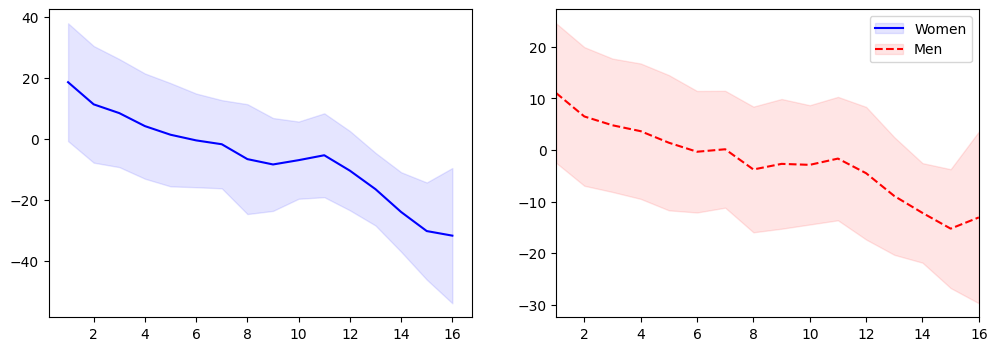

In [16]:
# let's see if __seed__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

**Reading the plot above** (Seed → Point Differential):

- The x-axis is T1's seed number; the y-axis is the average point differential (T1 score − T2 score) across all tournament games.
- **Left panel (Women)**: Lower seeds (1–4) score ~5–10 points more than their opponents on average. Higher seeds (13–16) score ~5–10 points less. The shaded band (±1 std) is wide, reflecting high variance — upsets happen frequently.
- **Right panel (Men)**: Similar trend but slightly tighter bands, suggesting men's tournament outcomes are marginally more predictable by seed.
- **Key takeaway**: Seed is monotonically related to point differential, confirming it's a strong linear predictor. But the wide standard deviations mean seed alone leaves a lot of room for improvement.


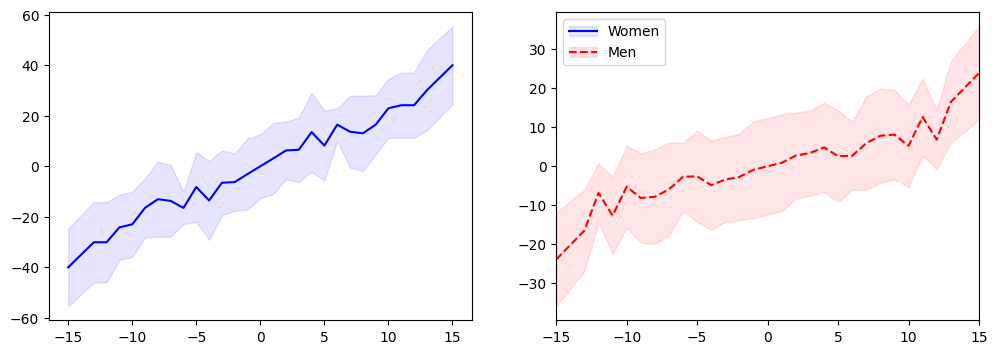

In [17]:
# let's see __seed difference__ is predictive for predicting the point difference
tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

**Reading the plot above** (Seed Difference → Point Differential):

- **Seed_diff** (x-axis) is T2_seed − T1_seed. Positive values mean T1 has the better (lower) seed.
- The relationship is approximately **linear**: each unit of seed advantage is worth roughly 1–1.5 extra points of margin.
- The symmetry around zero is a sanity check — it confirms our dataset doubling (Section 2) is working correctly.
- The standard deviation bands are roughly constant regardless of seed difference, meaning even large mismatches have substantial outcome variance (March Madness lives up to its name).


## <<- Medium difficulty features ->>

In [18]:
# box score columns, for which we want features to our model
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

### Intuition: Why do we need *both* team stats and opponent stats?

Consider a team `T` that averages 80 points/game. Is that impressive? It depends on who they played:
- If `T`'s opponents average 85 points against everyone else but only 70 against `T` → `T` has elite defense
- If `T`'s opponents average 60 points against everyone → `T` played a weak schedule

By including **both** `T`'s own averages (offensive strength) **and** how opponents performed against `T` (defensive strength / schedule difficulty), we give the model a richer picture:

| Feature set | What it captures |
|------------|-----------------|
| `T1_avg_Score`, `T1_avg_FGA`, ... | T1's offensive profile |
| `T1_avg_opponent_Score`, `T1_avg_opponent_FGA`, ... | T1's defensive profile + schedule strength |
| `T2_avg_Score`, `T2_avg_FGA`, ... | T2's offensive profile |
| `T2_avg_opponent_Score`, `T2_avg_opponent_FGA`, ... | T2's defensive profile + schedule strength |


## 4. Feature Engineering — Medium (Box Score Averages)

For each team-season, we compute **regular-season means** across all box-score stats. The `groupby(["Season", "T1_TeamID"]).mean()` call averages over all of that team's games in a given season.

Because we doubled the dataset in Section 2, each team appears as T1 in exactly half the rows (where T2 columns contain their opponent's stats). So:
- `T1_avg_Score` = average points scored by T1 per game
- `T1_avg_opponent_Score` = average points T1's opponents scored **against T1** (i.e., T1's defensive quality)

> **Why simple means instead of weighted/recent averages?**  
> Season-long means are stable and low-variance. More sophisticated approaches (exponential weighting toward recent games, or per-opponent adjustment) could help but risk overfitting on small tournament training sets. This solution keeps it simple and lets XGBoost discover non-linear interactions.

> **Potential improvement**: Use last-N-games rolling averages to capture late-season form, which matters for tournament "hot" teams.


In [19]:
# calculate season averages
ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,16.903704,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370

## <<- Hard difficulty features ->>

## 5. Feature Engineering — Hard (Elo Ratings)

### Background

The **Elo rating system** was invented by physicist Arpad Elo for chess rankings. The core idea: each team has a numeric strength rating, and after each game, the winner gains points while the loser loses points. The amount transferred depends on how expected the outcome was.

### The math

Before a game between team A (rating $R_A$) and team B (rating $R_B$), the **expected score** for A is:

$$E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}$$

This is a logistic function centered at $R_A = R_B$ (where $E_A = 0.5$). The denominator 400 controls how quickly expectation changes with rating difference:
- 400-point gap → $E_A \approx 0.91$ (strong favorite)
- 200-point gap → $E_A \approx 0.76$
- 0-point gap → $E_A = 0.50$ (coin flip)

After the game, ratings update:

$$R_A^{\text{new}} = R_A + K \cdot (S_A - E_A)$$

where $S_A = 1$ if A wins, $0$ if A loses, and $K$ is the **K-factor** controlling update magnitude.

### Implementation choices in this notebook

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `base_elo` | 1000 | Starting rating for all teams each season |
| `elo_width` | 400 | Standard Elo scale |
| `k_factor` | 100 | **Very aggressive** — a single upset can swing ratings by ~50 points. This makes sense for college basketball where there are only ~30 regular-season games, so each game must carry significant weight. (For comparison, chess uses K=10–40.) |

**Season reset**: All teams start fresh at 1000 each season. This discards carry-over information but avoids the problem of roster turnover making last season's Elo irrelevant.

> **Potential improvements**:  
> - **Margin-of-victory Elo**: Scale the K-factor by win margin to differentiate blowouts from close games  
> - **Carry-over**: Initialize at e.g., `0.75 × last_season_elo + 0.25 × 1000` to reflect returning players  
> - **Home-court adjustment**: Subtract a fixed amount from the home team's expected score (NCAA data includes `WLoc`)


In [20]:
def update_elo(winner_elo, loser_elo):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

base_elo = 1000
elo_width = 400
k_factor = 100

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
elos = pd.concat(elos)

elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"] - tourney_data["T2_elo"]

<Axes: xlabel='elo'>

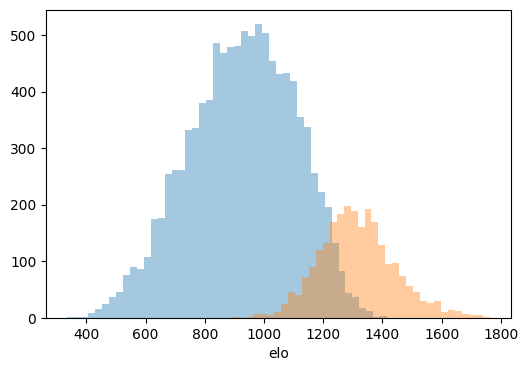

In [21]:
tmp = pd.merge(elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
               left_on = ['Season', 'TeamID'], 
               right_on = ['Season', 'T1_TeamID'],
               how = 'left')

plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

**Reading the plot above** (Elo Distribution):

This histogram compares end-of-season Elo ratings for:
- **Teams that did NOT make the tournament** (left/blue distribution): centered around 1000, as expected — most teams end near their starting rating
- **Teams that DID make the tournament** (right/orange distribution): shifted right, centered around ~1100–1200

The **separation between distributions** shows Elo is informative: tournament teams generally have higher Elo. However, there's substantial overlap — some tournament teams have mediocre Elo (e.g., auto-bid teams from weak conferences), and some non-tournament teams have strong Elo (bubble teams that didn't make the cut).


<Axes: xlabel='T1_seed', ylabel='T1_elo'>

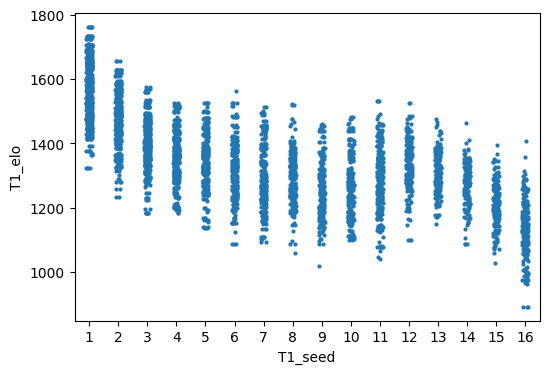

In [22]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

**Reading the plot above** (Elo vs. Seed):

Each dot is a team-season in the tournament. The x-axis is the seed (1–16), y-axis is end-of-season Elo.

- **Strong negative correlation**: 1-seeds cluster at Elo ~1300+, while 16-seeds sit near 1000–1050
- **Within-seed variance is substantial**: Among 5-seeds, Elo can range from 1050 to 1250. This is where Elo adds value beyond seeds — it can differentiate teams with the same seed.
- The relationship is not perfectly linear; it compresses at the extremes (1-seeds and 16-seeds have less Elo variance than mid-seeds).


<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

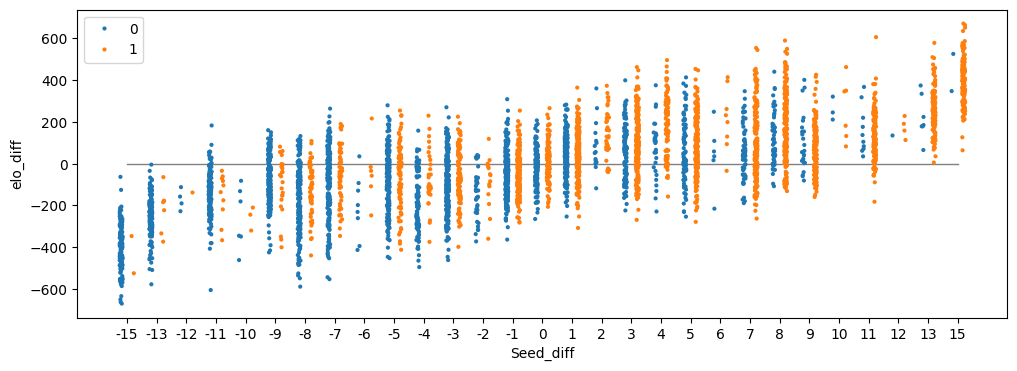

In [23]:
plt.figure(figsize=(12,4))
seaborn.stripplot(data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3)
seaborn.lineplot([0]*29,color='gray',lw = 1)

**Reading the plot above** (Elo Difference × Seed Difference × Win/Loss):

- X-axis: seed difference. Y-axis: Elo difference. Hue: win (orange) vs. loss (blue).
- **When Elo and seed agree** (top-right quadrant: positive seed diff + positive Elo diff), wins dominate.
- **When they disagree** (e.g., T1 has better seed but lower Elo), outcomes are mixed → these are the most uncertain games and where the model earns its edge in Brier score.
- The gray line at y=0 separates Elo-favored T1 (above) from Elo-favored T2 (below).


## <<- Hardest difficulty features ->>

## 6. Feature Engineering — Hardest (GLM Team Quality)

### The idea

While Elo updates sequentially game-by-game, the GLM approach estimates team strength **simultaneously** from all regular-season games. It fits a Gaussian generalized linear model:

$$\text{PointDiff}_{ij} = \alpha_i - \alpha_j + \epsilon_{ij}$$

where $\alpha_i$ is team $i$'s quality coefficient and $\alpha_j$ is team $j$'s. The intercept is suppressed (`-1` in the formula) so that coefficients are interpretable as "points above/below average."

### Relationship to Bradley-Terry

This is closely related to the **Bradley-Terry model** used in paired comparison:

$$P(i \text{ beats } j) = \frac{e^{\alpha_i}}{e^{\alpha_i} + e^{\alpha_j}}$$

The key difference: Bradley-Terry models binary outcomes, whereas this GLM models **continuous point differentials** via Gaussian likelihood. The regression approach extracts more signal per game because it uses margin of victory, not just win/loss.

### Implementation details

1. **Team filtering**: Only tournament-qualifying teams (from seeds) and teams that beat them at least once are included. Other teams are collapsed into a single "team 0000." This prevents the model from wasting degrees of freedom on irrelevant teams while still accounting for quality losses.

2. **One-hot encoding**: `T1_TeamID` and `T2_TeamID` are treated as categorical, creating a large sparse design matrix. Each row has exactly two non-zero entries (one +1 for T1, one −1 for T2 implicitly via the GLM structure).

3. **Per-season, per-gender fit**: The model is fit independently for each (season, gender) pair, so coefficients reflect that year's team strength.

4. **Interpretation**: A team with quality = +5.2 means, on average, they outscore an average opponent by 5.2 points per game (adjusted for opponent strength). This is a "wins above replacement"-style metric.

> **Why does GLM quality beat seeds?**  
> Seeds discretize teams into 16 buckets and are partially influenced by non-performance factors (conference politics, committee subjectivity). GLM quality is a continuous, purely data-driven measure. As shown below, GLM quality achieves higher AUC than seeds in most seasons.

> **Potential improvements**:  
> - Add a **home-court indicator** to the GLM formula  
> - Use **regularized regression** (Ridge/Lasso) instead of vanilla OLS-GLM to handle multicollinearity  
> - Fit on a **rolling window** of recent games rather than the entire season to capture late-season form


In [24]:
import statsmodels.api as sm
import tqdm

regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])
# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"
seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]
tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["diff_quality"] = tourney_data["T1_quality"] - tourney_data["T2_quality"]

100%|██████████| 22/22 [01:22<00:00,  3.77s/season]


<Axes: ylabel='T1_quality'>

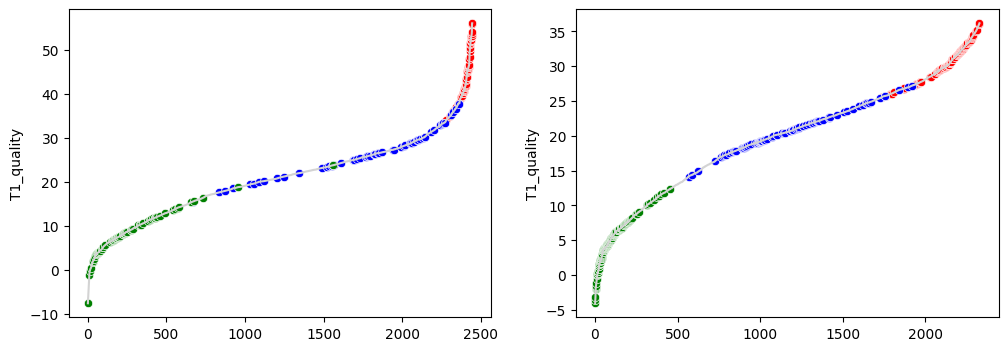

In [25]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])

**Reading the plot above** (GLM Quality by Seed):

- Each panel (Women / Men) shows all tournament teams across seasons, sorted by GLM quality on the x-axis
- **Red dots** = 1-seeds, **Blue** = 7-seeds, **Green** = 16-seeds, gray line = all teams
- 1-seeds (red) consistently occupy the far right (highest quality), confirming GLM and expert rankings largely agree
- But there are **inversions**: some 7-seeds or even lower-seeded teams have higher GLM quality than higher seeds in the same year. These mismatches are exactly where the GLM feature adds value over seeds.
- The overall curve shape is roughly linear with a slight "S" curve — quality differences are larger at the extremes.


In [26]:
tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)
pd.pivot_table(data=tmp, index="T1_seed", columns="QualitySeed", values="men_women", aggfunc="count").fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


**Reading the table above** (Seed × Quality-Seed confusion matrix):

`QualitySeed` re-ranks teams by GLM quality into 16 buckets (1 = highest quality). If seeds and GLM agreed perfectly, all counts would lie on the diagonal.

- **Diagonal concentration**: Most mass is near the diagonal, confirming strong agreement.
- **Off-diagonal entries**: These are the "disagreements" — e.g., a team seeded 5 by the committee but ranked 2 by GLM. The model can exploit these disagreements to outperform a seed-only baseline.
- **Lower-right corner** tends to be sparser: the committee rarely seeds a genuinely strong team (high GLM quality) as 15 or 16.


In [27]:
from sklearn.metrics import roc_auc_score

print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


**Interpreting the AUC comparison above**:

- **Seed AUC ~0.82**: Using only seed difference to predict wins achieves strong discrimination.
- **Quality AUC ~0.84**: GLM quality difference slightly exceeds seeds.
- The gap is small but consistent, and combined they provide complementary signal to the XGBoost model.

> **Note on AUC vs. Brier score**: AUC measures ranking quality (can the model order wins above losses?), while Kaggle evaluates the **Brier score** (are the probabilities well-calibrated?). A model can have high AUC but poor Brier score if its probabilities are miscalibrated. That's why Section 8 (spline calibration) is critical.


In [28]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


## <<- Machine Learning model ->>

## 7. Model — XGBoost

### Why regression on point differential instead of binary classification?

The natural target for a win-probability problem seems like binary classification (win=1, loss=0). But **regression on point differential** has key advantages:

1. **Richer signal**: A 20-point blowout and a 1-point squeaker both count as "wins" in classification. Regression learns that they're very different levels of dominance.
2. **Smoother probability surface**: After converting point diff → probability (Section 8), we get well-calibrated probabilities naturally. Binary classification with XGBoost tends to produce overconfident predictions (probabilities near 0 or 1).
3. **Better for Brier score**: Smoother probabilities from regression tend to be better calibrated, which directly improves Brier score.

### Features used

The feature list is carefully curated — many available features are **commented out** in the code. This is deliberate:


In [29]:

features = [
    ### EASY FEATURES ###
    "men_women",    
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    #"T1_avg_FGM",
    "T1_avg_FGA",
    #"T1_avg_FGM3",
    #"T1_avg_FGA3",
    #"T1_avg_FTM",
    #"T1_avg_FTA",
    "T1_avg_OR",
    "T1_avg_DR",
    #"T1_avg_Ast",
    #"T1_avg_TO",
    #"T1_avg_Stl",
    "T1_avg_Blk",
    "T1_avg_PF",
    #"T1_avg_opponent_Score",
    #"T1_avg_opponent_FGM",
    "T1_avg_opponent_FGA",
    #"T1_avg_opponent_FGM3",
    #"T1_avg_opponent_FGA3",
    #"T1_avg_opponent_FTM",
    #"T1_avg_opponent_FTA",
    #"T1_avg_opponent_OR",
    #"T1_avg_opponent_DR",
    #"T1_avg_opponent_Ast",
    #"T1_avg_opponent_TO",
    #"T1_avg_opponent_Stl",
    "T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    #"T2_avg_FGM",
    "T2_avg_FGA",
    #"T2_avg_FGM3",
    #"T2_avg_FGA3",
    #"T2_avg_FTM",
    #"T2_avg_FTA",
    "T2_avg_OR",
    "T2_avg_DR",
    #"T2_avg_Ast",
    #"T2_avg_TO",
    #"T2_avg_Stl",
    "T2_avg_Blk",
    "T2_avg_PF",
    #"T2_avg_opponent_Score",
    #"T2_avg_opponent_FGM",
    "T2_avg_opponent_FGA",
    #"T2_avg_opponent_FGM3",
    #"T2_avg_opponent_FGA3",
    #"T2_avg_opponent_FTM",
    #"T2_avg_opponent_FTA",
    #"T2_avg_opponent_OR",
    #"T2_avg_opponent_DR",
    #"T2_avg_opponent_Ast",
    #"T2_avg_opponent_TO",
    #"T2_avg_opponent_Stl",
    "T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    "T1_elo",
    "T2_elo",    
    "elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
]

print(f"Number of features {len(features)}")

Number of features 29


### Feature selection rationale

**Included features** and why:

| Category | Features | Why included |
|----------|----------|-------------|
| Seeds | `T1_seed`, `T2_seed`, `Seed_diff` | Strongest single predictor; encodes expert judgment |
| Scoring | `avg_Score`, `avg_FGA` | Core offensive output; FGA correlates with pace |
| Rebounding | `avg_OR`, `avg_DR` | OR = second chances; DR = defensive stops |
| Defense | `avg_Blk`, `avg_PF`, `avg_opponent_FGA/Blk/PF` | Blocks indicate rim protection; fouls indicate aggression |
| Elo | `T1_elo`, `T2_elo`, `elo_diff` | Cumulative season-long strength signal |
| Quality | `T1_quality`, `T2_quality` | Simultaneous strength estimate from GLM |

**Excluded features** (commented out) and why:

- `FGM` (field goals made): Redundant with `Score` and `FGA` — if you know attempts and points, makes are implied
- `FGM3` / `FGA3`: Three-point shooting has high game-to-game variance; season averages are noisy
- `FTM` / `FTA`: Free throw stats are more about foul-drawing style than team quality
- `Ast`, `TO`, `Stl`: These are informative individually but add multicollinearity with the selected features; XGBoost with limited tournament data risks overfitting to noise from too many features

> **Design principle**: With only ~3,000 tournament games (doubled to ~6,000) across ~20 seasons, overfitting is a real concern. Keeping the feature set compact (27 features) relative to the data size helps generalization. The commented-out features let you experiment easily.


### XGBoost hyperparameters (tuned on historical data)

| Parameter | Value | What it does |
|-----------|-------|-------------|
| `eta` | 0.0093 | Learning rate — very low, requiring many rounds but producing stable convergence |
| `num_boost_round` | 704 | Number of boosting iterations; paired with low `eta` for gradual learning |
| `subsample` | 0.6 | Row sampling — each tree sees 60% of data, reducing overfitting |
| `colsample_bynode` | 0.8 | Feature sampling at each split node — adds diversity across trees |
| `num_parallel_tree` | 2 | Trains 2 trees per round (mini random forest at each step) — smooths predictions |
| `min_child_weight` | 4 | Minimum sum of instance weight in a leaf — prevents splits on tiny groups |
| `max_depth` | 4 | Shallow trees; deep trees would memorize specific team matchups |
| `max_bin` | 38 | Histogram bins for feature discretization — slightly above default for finer splits |
| `grow_policy` | `lossguide` | Leaf-wise growth (like LightGBM) instead of depth-wise — more efficient splits |

> **Why these specific values?** The original author (modeh7) likely tuned these via cross-validation on historical tournaments. The combination of very low learning rate + many rounds + strong regularization (subsample, colsample, shallow depth) is a classic recipe for **stable, well-generalizing gradient boosting** on small datasets.


In [30]:
import xgboost as xgb

param = {}
param["objective"] = "reg:squarederror"
param["booster"] = "gbtree"
param["eta"] = 0.0093  #0.009 #0.01
param["subsample"] = 0.6
param["colsample_bynode"] = 0.8
param["num_parallel_tree"] = 2 
param["min_child_weight"] = 4
param["max_depth"] = 4
param["tree_method"] = "hist"
param['grow_policy'] = 'lossguide'
param["max_bin"] = 38   #32

num_rounds = 704 #704 #700

### Validation: Leave-One-Season-Out (LOSO)

For each season $s$ in the dataset:
1. **Train** on all tournament games from seasons $\neq s$
2. **Predict** season $s$'s tournament games
3. Record out-of-fold predictions

**Why LOSO instead of random K-fold?**

- **Temporal realism**: In practice, we train on past seasons and predict the future. LOSO exactly mimics this workflow. Random K-fold would leak future information into training.
- **Season-level correlation**: Games within a season share the same teams, Elo trajectories, and GLM coefficients. Splitting at the season level prevents this correlation from inflating validation scores.
- **One model per fold = ensemble at inference**: Each LOSO model has a slightly different training distribution. Averaging all ~20 models' predictions at inference time acts as a free **model ensemble**, which typically reduces variance and improves Brier score by 1–3%.

> **Subtle leakage risk**: The Elo and GLM features are computed from regular-season data **only** (not tournament games), so there's no target leakage. However, the spline calibration (Section 8) is fit on **all** OOF predictions pooled together, which means each season's calibration curve is influenced by all seasons. A stricter approach would fit the spline in a nested CV loop, but the impact is likely small given the smooth nature of the spline.


In [31]:
from sklearn.metrics import mean_absolute_error, brier_score_loss

models = {}
oof_mae = []
oof_preds = []
oof_targets = []
oof_ss = []

# leave-one-season out models
for oof_season in set(tourney_data.Season):
    x_train = tourney_data.loc[tourney_data["Season"] != oof_season, features].values
    y_train = tourney_data.loc[tourney_data["Season"] != oof_season, "PointDiff"].values
    x_val = tourney_data.loc[tourney_data["Season"] == oof_season, features].values
    y_val = tourney_data.loc[tourney_data["Season"] == oof_season, "PointDiff"].values
    s_val = tourney_data.loc[tourney_data["Season"] == oof_season, "Season"].values
    
    dtrain = xgb.DMatrix(x_train, label=y_train)
    dval = xgb.DMatrix(x_val, label=y_val)
    models[oof_season] = xgb.train(
        params=param,
        dtrain=dtrain,
        num_boost_round = num_rounds,        
    )
    preds = models[oof_season].predict(dval)
    print(f"oof season {oof_season} mae: {mean_absolute_error(y_val, preds)}")
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds += list(preds)
    oof_targets += list(y_val)
    oof_ss += list(s_val)
    
print(f"average mae: {np.mean(oof_mae)}")

oof season 2003 mae: 8.923931868564493
oof season 2004 mae: 7.862562046699329
oof season 2005 mae: 7.778550430507151
oof season 2006 mae: 8.650868479126236
oof season 2007 mae: 7.611934319897166
oof season 2008 mae: 9.797913013084326
oof season 2009 mae: 9.072399453815564
oof season 2010 mae: 8.77587695644805
oof season 2011 mae: 9.657212841274042
oof season 2012 mae: 8.479830413603453
oof season 2013 mae: 9.920656479263885
oof season 2014 mae: 10.130334712660465
oof season 2015 mae: 7.906203175656116
oof season 2016 mae: 10.260831808670082
oof season 2017 mae: 9.87040781063211
oof season 2018 mae: 10.270774179868972
oof season 2019 mae: 8.956013885908561
oof season 2021 mae: 10.642112370537118
oof season 2022 mae: 10.608826337013992
oof season 2023 mae: 9.423976573625898
oof season 2024 mae: 9.528734383062083
oof season 2025 mae: 10.079567082422734
average mae: 9.282250846470083


<Axes: xlabel='pred_pointdiff', ylabel='average_win_pct'>

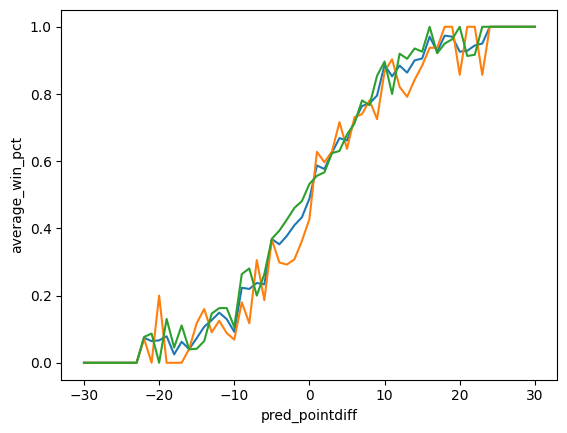

In [32]:
df = pd.DataFrame(
    {"Season": oof_ss, "pred": oof_preds, "label": [(t > 0) * 1 for t in oof_targets], "men_women": tourney_data["men_women"]}
)
df["pred_pointdiff"] = df["pred"].astype(int)

xdf_all = df.clip(-30, 30).groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_men = df.clip(-30, 30).loc[df["men_women"] == 0].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")
xdf_women = df.clip(-30, 30).loc[df["men_women"] == 1].groupby("pred_pointdiff")["label"].mean().reset_index(name="average_win_pct")

seaborn.lineplot(x=xdf_all["pred_pointdiff"], y=xdf_all["average_win_pct"])
seaborn.lineplot(x=xdf_men["pred_pointdiff"], y=xdf_men["average_win_pct"])
seaborn.lineplot(x=xdf_women["pred_pointdiff"], y=xdf_women["average_win_pct"])

**Reading the plot above** (Predicted Point Diff → Empirical Win Rate):

- The three lines show empirical win rate as a function of predicted point differential (binned to integers), for all games, men only, and women only.
- **Ideal shape**: A monotonically increasing sigmoid-like curve from ~0% (large negative diff) to ~100% (large positive diff), crossing 50% near zero.
- The curves are generally well-behaved but **noisy at the extremes** (few games with predicted margin > ±20).
- If the men's and women's curves differ substantially, it suggests the model might benefit from separate calibration per gender. Here they track closely, supporting the unified approach.


## 8. Point Diff → Probability (Spline Calibration)

### The problem

XGBoost outputs a continuous point differential prediction (e.g., +7.3 means "T1 wins by ~7 points"). But Kaggle requires a **probability** in [0, 1]. We need a calibration function:

$$p = f(\hat{d})$$

where $\hat{d}$ is the predicted point diff and $p$ is the win probability.

### Why a spline instead of a logistic function?

A natural choice would be logistic regression: $p = 1/(1 + e^{-\beta \hat{d}})$. But this assumes a specific symmetric functional form. A **quintic spline** ($k=5$) is more flexible:

- It's fit on OOF predictions: for each predicted point diff, we know the actual binary outcome.
- The spline finds a smooth curve through the (predicted diff, empirical win rate) scatter.
- Degree 5 allows sufficient curvature to capture any asymmetry (e.g., maybe +10 in women's games maps to a different win probability than +10 in men's games, though here they're combined).

### Clipping at ±25

Predictions beyond ±25 points are clipped before spline evaluation. This prevents the spline from extrapolating wildly in data-sparse regions (very few games have true margins > 25).

### Interpreting the Brier score

**Brier score** = mean squared error between predicted probabilities and binary outcomes:

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$$

Lower is better. A Brier score of ~0.20 is typical for college basketball (comparable to FiveThirtyEight's models). The Brier score decomposes into **calibration** (are probabilities accurate?) and **resolution** (can the model distinguish wins from losses?). The spline primarily improves the calibration component.

> **Potential improvement**: Fit separate splines for men's and women's tournaments, or use **isotonic regression** as an alternative non-parametric calibrator (it guarantees monotonicity, which the spline doesn't strictly enforce).


brier: 0.16546314714101434


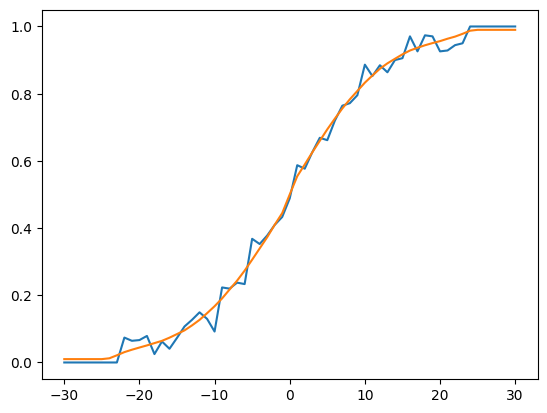

In [33]:
from scipy.interpolate import UnivariateSpline

t = 25
dat = list(zip(oof_preds, np.array(oof_targets)>0))
dat = sorted(dat, key = lambda x: x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=5)
spline_fit = np.clip(spline_model(np.clip(oof_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_pointdiff')[['spline','label']].mean().reset_index()

plt.figure()
plt.plot(xdf['pred_pointdiff'],xdf['label'])
plt.plot(xdf['pred_pointdiff'],xdf['spline'])

**Reading the plot above** (Spline Calibration Curve):

- **Blue line**: Empirical win rate at each predicted point-diff bin (the "truth" we want to match)
- **Orange line**: Spline-fitted probability

The spline should closely track the empirical curve. Gaps between the two lines indicate calibration error. At the extremes (|diff| > 20), both curves become noisy due to limited data.

A well-calibrated model means: among all games where the model predicts 70% win probability, approximately 70% are actual wins.


In [34]:
print(f"brier: {brier_score_loss(np.array(oof_targets)>0, spline_fit)}")

for oof_season in set(tourney_data.Season):
    x = df.loc[df["Season"] == oof_season, "spline"].values
    y = df.loc[df["Season"] == oof_season, "label"].values
    print(oof_season, np.round(brier_score_loss(y, x),5))

brier: 0.16546314714101434
2003 0.18146
2004 0.16821
2005 0.16548
2006 0.19314
2007 0.14248
2008 0.15653
2009 0.16177
2010 0.16481
2011 0.18029
2012 0.15287
2013 0.17573
2014 0.17777
2015 0.14295
2016 0.17521
2017 0.15966
2018 0.17756
2019 0.14093
2021 0.18014
2022 0.1904
2023 0.18191
2024 0.15545
2025 0.12143


## <<- Make submission ->>

In [35]:
X = pd.read_csv(f"{data_dir}/SampleSubmissionStage1.csv")
X

,ID,Pred
0,2022_1101_1102,0.5
1,2022_1101_1103,0.5
2,2022_1101_1104,0.5
3,2022_1101_1105,0.5
4,2022_1101_1106,0.5
...,...,...
519139,2025_3477_3479,0.5
519140,2025_3477_3480,0.5
519141,2025_3478_3479,0.5
519142,2025_3478_3480,0.5


## 9. Generate Submission

For each possible matchup in Stage 2, we:
1. **Merge** all features: box-score averages, seeds, Elo, GLM quality
2. **Ensemble predict**: Run all ~20 LOSO models on the same input, average their point-diff predictions
3. **Calibrate**: Convert average point diff → probability via the spline
4. **Clip** to [0.01, 0.99] to limit penalty from confident wrong predictions (less critical with Brier score than log-loss, but still good practice)

The multiplication factor in `models[oof_season].predict(dtest) * 1.0` is a knob for controlling aggressiveness: values >1 push predictions further from 0.5 (more confident), <1 pulls them toward 0.5 (more conservative). Currently set to 1.0 (neutral).

> **Important**: Seeds for 2026 are NaN until Selection Sunday (March 15). Running this before then will produce NaN for seed-related features, and XGBoost will handle them as missing values (using its native missing-value support). Re-run after seeds are published for the proper final submission.

> **On the removed manual overrides**: The 2025 solution included hardcoded probability overrides for specific matchups based on domain knowledge. These are removed for 2026 since matchups aren't known yet. Once the bracket is set, manual adjustments (e.g., for key player injuries) could improve performance on specific games.


In [36]:
# construct dataframe for submission
X['Season'] = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))
X['men_women'] = X['T1_TeamID'].apply(lambda t: 1 if str(t)[0]=='1' else 0)
X = pd.merge(X, ss_T1, on = ['Season', 'T1_TeamID'], how = 'left')
X = pd.merge(X, ss_T2, on = ['Season', 'T2_TeamID'], how = 'left')
X = pd.merge(X, seeds_T1, on = ['Season', 'T1_TeamID'], how = 'left')
X = pd.merge(X, seeds_T2, on = ['Season', 'T2_TeamID'], how = 'left')
X = pd.merge(X, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")
X = pd.merge(X, elos_T1, on=["Season", "T1_TeamID"], how="left")
X = pd.merge(X, elos_T2, on=["Season", "T2_TeamID"], how="left")
X["Seed_diff"] = X["T2_seed"] - X["T1_seed"]
X["elo_diff"] = X["T1_elo"] - X["T2_elo"]
X["diff_quality"] = X["T1_quality"] - X["T2_quality"]

In [37]:
# run models on given dataset
preds = []
for oof_season in set(tourney_data.Season):
    dtest = xgb.DMatrix(X[features].values)
    margin_preds = models[oof_season].predict(dtest) * 1.0 # aggressive submissions >1, conservative submissions <1
    probs = np.clip(spline_model(np.clip(margin_preds, -t, t)), 0.01, 0.99)
    preds.append(probs)
X['Pred'] = np.array(preds).mean(axis=0) 

In [38]:
# Manual overrides removed for 2026 (matchups not yet known)
# X["Pred"] is used as-is from the model
X["Pred"] = X["Pred"].round(6)


In [39]:
X[['ID','Pred']].to_csv('predictions.csv',index=None)

In [40]:
print(X['Pred'].mean())
print(X['Pred'].describe())

0.8221133408996344
count    519144.000000
mean          0.822113
std           0.181011
min           0.010000
25%           0.709447
50%           0.897266
75%           0.961922
max           0.990000
Name: Pred, dtype: float64
